# SEC Filing Discovery: Point-in-Time Metadata Integrity

**Docker image**: `ml4t`

**Chapter 22: RAG for Financial Research - §22.3 Intelligent Document Ingestion**

**Learning Objectives**
- Use `edgartools` to list 10-K filings for a symbol universe and capture
  the metadata fields a RAG system needs for point-in-time retrieval.
- Verify metadata integrity (filing date, ingestion timestamp, fiscal period)
  so downstream chunking and retrieval cannot accidentally leak the future.
- State the parser-mode contract that downstream embedding and retrieval
  notebooks build on without presenting unmeasured quality scores.

**Prerequisites**: None. The notebook is self-contained and pairs naturally
with `05_10k_rag_assistant` for downstream indexing and querying.

**Book reference**: §22.3 covers the document-ingestion failure modes that
this notebook's metadata-integrity scaffolding is designed to prevent.

Filings discovered here feed `05_10k_rag_assistant`, which indexes the same
10-K corpus and demonstrates citation-constrained answering.

## Setup

The symbol universe and filing years are exposed as Papermill parameters.
The canonical 10-K corpus is loaded via `data.load_sec_filings("10-K",
universe="sp100")`; this notebook records where that corpus lives
for downstream RAG notebooks (Ch22 NB02-08).

In [1]:
"""SEC Filing Ingestion - edgartools-based pipeline with metadata integrity checks."""

import os
import time
import warnings
from datetime import UTC, datetime

warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import polars as pl
from edgar import Company, set_identity
from plotly.subplots import make_subplots

from utils.config import ML4T_DATA_PATH
from utils.style import COLORS

In [2]:
SYMBOLS = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]
YEARS = [2023, 2024]

In [3]:
# Canonical SP100 10-K corpus (downloaded by data/equities/fundamentals/filings_download.py).
SP100_10K_PARQUET = (
    ML4T_DATA_PATH
    / "equities"
    / "fundamentals"
    / "10k"
    / "sp100"
    / "reference"
    / "all_10k_filings.parquet"
)
if not SP100_10K_PARQUET.exists():
    raise FileNotFoundError(
        "Canonical SP100 10-K corpus is missing. Run "
        "data/equities/fundamentals/filings_download.py first."
    )

In [4]:
print(f"Symbols: {SYMBOLS}")
print(f"Years: {YEARS}")
print(f"Filing storage: {SP100_10K_PARQUET}")

Symbols: ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN']
Years: [2023, 2024]
Filing storage: ~/Dropbox/ml4t/data/equities/fundamentals/10k/sp100/reference/all_10k_filings.parquet


## Listing 10-K Filings with edgartools

`edgartools` exposes the SEC EDGAR submissions feed via a `Company` object.
The library handles symbol-to-CIK resolution, returns filings with their
accession numbers and filing dates, and provides a clean interface to XBRL
financial data for further enrichment.

Per SEC fair-access requirements, a real identity string is required before
any request. The notebook refuses to run with a missing identity rather than
sending a placeholder User-Agent.

In [5]:
edgar_identity = os.environ.get("EDGAR_IDENTITY")
if not edgar_identity:
    raise RuntimeError(
        "EDGAR_IDENTITY is not set. The SEC requires a real User-Agent - your "
        "name and email - on every EDGAR request, and blocks placeholder "
        "addresses. It is not an API key and there is nothing to sign up for.\n"
        "Put your own name and email on the EDGAR_IDENTITY line of the .env "
        "file in the repository root:\n"
        "    EDGAR_IDENTITY=Jane Doe jane@example.org\n"
        ".env is read once, when the process starts, so then restart this "
        "notebook's kernel (Kernel -> Restart Kernel). On the Docker path, stop "
        "Jupyter Lab and run `docker compose up ml4t` again - `docker compose "
        "restart` keeps the environment the container was created with."
    )
set_identity(edgar_identity)
print("edgartools configured with a non-placeholder SEC identity")

edgartools configured with a non-placeholder SEC identity


### Helper: list 10-K filings for a single symbol

Returns one record per filing with the metadata fields that downstream
point-in-time filtering and citation formatting depend on.

In [6]:
def list_10k_filings(symbol: str, years: list[int]) -> dict:
    """List 10-K filings for `symbol` whose public filing date falls in `years`."""
    results: dict = {"symbol": symbol, "filings": []}

    company = Company(symbol)
    print(f"\n{symbol}: {company.name} (CIK: {company.cik})")

    for filing in company.get_filings(form="10-K", amendments=False):
        if filing.filing_date.year in years:
            results["filings"].append(
                {
                    "accession_number": filing.accession_number,
                    "timestamp": filing.filing_date,
                    "period_end": filing.period_of_report,
                    "form": filing.form,
                }
            )
            print(f"  10-K: {filing.filing_date} (Accession: {filing.accession_number})")

    results["status"] = "success"
    results["filing_count"] = len(results["filings"])
    time.sleep(0.1)
    return results

### Run the lookup over the configured symbol universe

Each symbol hits the EDGAR submissions endpoint once. Filings are not
bulk-downloaded here - the goal is the metadata layer that downstream
notebooks need; the body of each 10-K is fetched on demand by indexing
notebooks.

In [7]:
edgartools_results = []
print("=== edgartools 10-K lookup ===")
start_time = time.time()

for symbol in SYMBOLS:
    edgartools_results.append(list_10k_filings(symbol, YEARS))

elapsed = time.time() - start_time
print(f"\nLookup completed in {elapsed:.2f}s")

=== edgartools 10-K lookup ===

AAPL: Apple Inc. (CIK: 320193)


  10-K: 2024-11-01 (Accession: 0000320193-24-000123)


  10-K: 2023-11-03 (Accession: 0000320193-23-000106)

MSFT: MICROSOFT CORP (CIK: 789019)


  10-K: 2024-07-30 (Accession: 0000950170-24-087843)


  10-K: 2023-07-27 (Accession: 0000950170-23-035122)

NVDA: NVIDIA CORP (CIK: 1045810)


...

  10-K: 2023-02-24 (Accession: 0001045810-23-000017)

GOOGL: Alphabet Inc. (CIK: 1652044)


  10-K: 2024-01-31 (Accession: 0001652044-24-000022)


  10-K: 2023-02-03 (Accession: 0001652044-23-000016)

AMZN: AMAZON COM INC (CIK: 1018724)


  10-K: 2024-02-02 (Accession: 0001018724-24-000008)
  10-K: 2023-02-03 (Accession: 0001018724-23-000004)



Lookup completed in 3.89s


## Coverage Summary

How many 10-K filings did the lookup find for each symbol? A row with
zero filings is a coverage hole that downstream RAG cannot recover from
- there is nothing to retrieve over.

In [8]:
coverage_df = pl.DataFrame(
    [
        {
            "symbol": r["symbol"],
            "status": r.get("status", "N/A"),
            "filings_found": r.get("filing_count", 0),
        }
        for r in edgartools_results
    ]
)
print("\n=== 10-K Coverage by Ticker ===")
coverage_df


=== 10-K Coverage by Ticker ===


symbol,status,filings_found
str,str,i64
"""AAPL""","""success""",2
"""MSFT""","""success""",2
"""NVDA""","""success""",2
"""GOOGL""","""success""",2
"""AMZN""","""success""",2


A coverage row with zero filings - for example a symbol whose 10-K filings
fall outside the configured year window - flags the universe as a
point-in-time mismatch rather than a retrieval bug. Fix it at the universe
level before indexing, not at query time.

## Point-in-Time Metadata Integrity

Historical analysis must filter by what was knowable at the decision date.
That requires every filing record to carry, at minimum:

- the filing date (when the document became public),
- the ingestion timestamp (when our system observed it), and
- the fiscal period end (so we can align quarterly/annual cycles).

The integrity check below quantifies how well those fields are populated.

In [9]:
ingestion_timestamp = datetime.now(UTC).isoformat(timespec="seconds")

metadata_rows = []
for symbol, result in zip(SYMBOLS, edgartools_results, strict=True):
    for filing in result.get("filings", []):
        metadata_rows.append(
            {
                "symbol": symbol,
                "timestamp": filing.get("timestamp"),
                "period_end": filing.get("period_end"),
                "ingestion_timestamp": ingestion_timestamp,
                "accession_number": filing.get("accession_number"),
            }
        )

metadata_df = pl.DataFrame(
    metadata_rows,
    schema={
        "symbol": pl.Utf8,
        "timestamp": pl.Date,
        "period_end": pl.Utf8,
        "ingestion_timestamp": pl.Utf8,
        "accession_number": pl.Utf8,
    },
).with_columns(pl.col("period_end").str.to_date(strict=False))

In [10]:
integrity_df = metadata_df.select(
    pl.len().alias("rows"),
    pl.col("timestamp").is_not_null().mean().alias("public_date_present"),
    pl.col("ingestion_timestamp").is_not_null().mean().alias("ingestion_ts_present"),
    pl.col("period_end").is_not_null().mean().alias("period_end_present"),
)
print("\n=== Metadata Integrity ===")
integrity_df


=== Metadata Integrity ===


rows,public_date_present,ingestion_ts_present,period_end_present
u32,f64,f64,f64
10,1.0,1.0,1.0


In [11]:
assert metadata_df.height == sum(r["filing_count"] for r in edgartools_results)
assert metadata_df["accession_number"].n_unique() == metadata_df.height
assert metadata_df["symbol"].n_unique() == len(SYMBOLS)
assert metadata_df["timestamp"].null_count() == 0
assert metadata_df["ingestion_timestamp"].null_count() == 0

Public filing date and ingestion timestamp must be complete. The public date
is only day-level here; a trading application should enrich it with the SEC
acceptance timestamp before making same-day availability claims.

## Coverage and Metadata Completeness

The left panel checks corpus coverage by issuer. The right panel separates
the public-date, observation-time, and reporting-period fields needed for
point-in-time filtering and citation provenance.

In [12]:
integrity_long = integrity_df.select(
    pl.col("public_date_present").alias("Public date"),
    pl.col("ingestion_ts_present").alias("Ingestion time"),
    pl.col("period_end_present").alias("Period end"),
).unpivot(variable_name="field", value_name="completeness")

min_filings = int(coverage_df["filings_found"].min())
complete_fields = int((integrity_long["completeness"] == 1.0).sum())
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("10-K filings by issuer", "Metadata completeness"),
    horizontal_spacing=0.16,
)
_ = fig.add_trace(
    go.Bar(
        x=coverage_df["symbol"].to_list(),
        y=coverage_df["filings_found"].to_list(),
        marker_color=COLORS["blue"],
        text=coverage_df["filings_found"].to_list(),
        textposition="outside",
        showlegend=False,
    ),
    row=1,
    col=1,
)
_ = fig.add_trace(
    go.Bar(
        x=integrity_long["field"].to_list(),
        y=integrity_long["completeness"].to_list(),
        marker_color=COLORS["amber"],
        text=[f"{value:.0%}" for value in integrity_long["completeness"]],
        textposition="outside",
        showlegend=False,
    ),
    row=1,
    col=2,
)

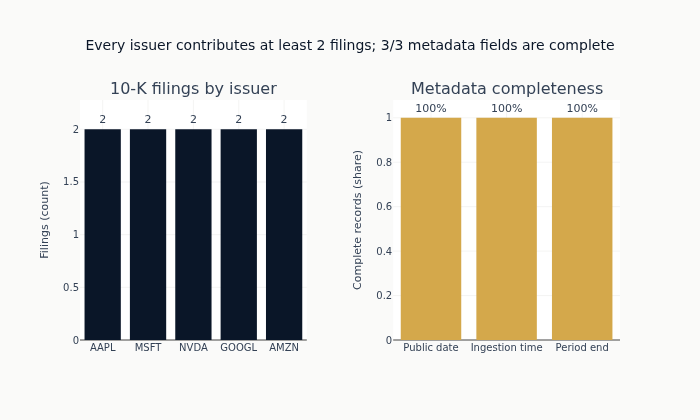

In [13]:
fig.update_layout(
    title=(
        f"Every issuer contributes at least {min_filings} filings; "
        f"{complete_fields}/3 metadata fields are complete"
    ),
    height=420,
)
fig.update_yaxes(title_text="Filings (count)", rangemode="tozero", row=1, col=1)
fig.update_yaxes(title_text="Complete records (share)", range=[0, 1.08], row=1, col=2)
fig.show()

## Parser-Mode Trade-Off

Once a filing's metadata is in hand, the next decision is *how* to break
the document into retrievable units. Two extreme parsing strategies bound
the design space:

- **Text-first** parsing strips structure and emits a single character
  stream. Fast and uniform, but tables fragment, headings detach from
  their sections, and chunking has nothing structural to anchor to.
- **Structure-aware** parsing preserves tables, headings, and list
  hierarchy. Slower per page, but downstream chunking can respect
  semantic units, and citations can resolve to a section rather than to
  a character offset.

This notebook does not benchmark parsers, so it does not attach numeric
quality or latency claims to either mode. A valid comparison needs a labelled
sample of prose, tables, headings, and footnotes, plus a measured runtime on
the same documents.

| Parser mode | Preserves | Primary risk |
|---|---|---|
| Text-first | Linear prose | Tables and section hierarchy may be lost |
| Structure-aware | Prose, tables, headings, lists | More extraction complexity |

## Pipeline Summary

In [14]:
total_filings = sum(r.get("filing_count", 0) for r in edgartools_results)
print("=== Pipeline Complete ===")
print(f"Symbols processed:           {len(SYMBOLS)}")
print(f"Total 10-K filings found:    {total_filings}")
print(f"Average filings per symbol:  {total_filings / len(SYMBOLS):.1f}")
print(f"Filing storage:              {SP100_10K_PARQUET}")

=== Pipeline Complete ===
Symbols processed:           5
Total 10-K filings found:    10
Average filings per symbol:  2.0
Filing storage:              ~/Dropbox/ml4t/data/equities/fundamentals/10k/sp100/reference/all_10k_filings.parquet


The pipeline-complete line records filing coverage from this notebook; the
parser-mode table above is a qualitative design contract, not a benchmark.

## Key Takeaways

1. `edgartools` resolves symbol to CIK and lists filings with filing date
   and accession number - the minimum metadata a financial RAG system
   needs to enforce point-in-time retrieval.
2. **Metadata integrity** is a precondition for citation traceability:
   `filing_date` and `ingestion_timestamp` must be present on every
   record; gaps in either field are coverage bugs, not retrieval bugs.
3. **Parser selection requires measured evidence**: structure-aware parsing
   offers the fields that table-aware retrieval needs, but its quality and
   latency must be benchmarked on labelled documents before deployment.

**Next**: filings indexed here feed `05_10k_rag_assistant` for the full
RAG pipeline. See also
[`02_domain_embeddings_comparison`](02_domain_embeddings_comparison.ipynb)
for embedding-model selection over this corpus.